In [40]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ----------------------------
# 1) CONFIG
# ----------------------------
CSV_PATH = "HW_Datos_Jal.csv"   # <-- ajusta si tu archivo está en otra ruta
MIN_DATE = "2010-01-31"
N_TRAIN = 146 #90% training
ALPHA = 0.05  # significancia para H0

# ----------------------------
# 2) NOMBRES DE ACTIVIDADES (sector_economico_2)
#    Asumimos que el código 0 corresponde al primer nombre, 1 al segundo, etc.
# ----------------------------
activity_names_list = [

]
activity_names = {i: n for i, n in enumerate(activity_names_list)}

In [41]:
# ----------------------------
# 3) CARGA Y LIMPIEZA DE DATOS
# ----------------------------
data = pd.read_csv(CSV_PATH)

# Ajuste de variable base (empleo)
# Si tu CSV no tiene HWES1, revisa el nombre real de la columna de empleo
data["ta"] = data["HWES1"]
data = data.drop(columns=["HWES1"], errors="ignore")

selected_data = data[["sector_economico_1", "sector_economico_2", "ta", "Año"]].copy()
selected_data["Año"] = pd.to_datetime(selected_data["Año"])
selected_data = selected_data[selected_data["Año"] > pd.to_datetime(MIN_DATE)]

# ----------------------------
# 4) CONSTRUIR MATRIZ TIEMPO x ACTIVIDAD (sector_economico_2)
# ----------------------------
agg = (selected_data
       .groupby(["Año", "sector_economico_2"])["ta"]
       .sum()
       .reset_index())

wide = (agg
        .pivot(index="Año", columns="sector_economico_2", values="ta")
        .sort_index()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0))

# Robustez: asegurar columnas numéricas int
wide.columns = pd.to_numeric(pd.Index(wide.columns), errors="coerce")
wide = wide.loc[:, ~wide.columns.isna()]
wide.columns = wide.columns.astype(int)

T = len(wide)
if T <= N_TRAIN + 2:
    raise ValueError(f"No hay suficientes periodos. T={T}, necesitas > {N_TRAIN}+2 (por el rezago).")

# ----------------------------
# 5) FUNCIONES
# ----------------------------
def r2_oos(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res/ss_tot if ss_tot != 0 else np.nan

def fit_one_activity_ar1_fullX(target_code: int, df_wide: pd.DataFrame, n_train: int):
    """
    Modelo:
    y_t = a + phi*y_{t-1} + sum_{j!=i} beta_j x_{j,t} + e_t
    usando TODAS las x_j,t disponibles (excepto target).
    """
    if target_code not in df_wide.columns:
        return None

    y = df_wide[target_code].copy()
    X_all = df_wide.drop(columns=[target_code]).copy()
    y_lag = y.shift(1).rename("y_lag1")

    # Alinear y, rezago y X contemporáneas
    Z = pd.concat([y.rename("y"), y_lag, X_all], axis=1).dropna()

    y_aligned = Z["y"]
    X_aligned = Z.drop(columns=["y"])

    # Split temporal sobre Z ya alineado
    y_train, y_test = y_aligned.iloc[:n_train], y_aligned.iloc[n_train:]
    X_train, X_test = X_aligned.iloc[:n_train], X_aligned.iloc[n_train:]

    # Quitar columnas constantes en TRAIN
    var = X_train.var(axis=0)
    X_train = X_train.loc[:, var > 0]
    X_test  = X_test.loc[:, X_train.columns]

    if X_train.shape[1] == 0 or len(y_test) == 0:
        return None

    X_train_c = sm.add_constant(X_train)
    X_test_c  = sm.add_constant(X_test)

    model = sm.OLS(y_train, X_train_c).fit()

    y_pred_test = model.predict(X_test_c)

    return {
        "Sector_code": int(target_code),
        "Sector": int(target_code),
        "R2_train": float(model.rsquared),
        "R2_test": float(r2_oos(y_test.values, y_pred_test.values)),
        "n_obs_train": int(len(y_train)),
        "n_obs_test": int(len(y_test)),
        "n_regressors": int(X_train.shape[1])  # incluye y_lag1 + (N-1) sectores (menos constantes)
    }

# ----------------------------
# 6) EJECUTAR: R2 TRAIN / TEST PARA TODOS LOS SECTORES
# ----------------------------
sector_codes = sorted(wide.columns.tolist())

results = []
for code in sector_codes:
    res = fit_one_activity_ar1_fullX(code, wide, N_TRAIN)
    if res is not None:
        results.append(res)

if len(results) == 0:
    raise ValueError("No se generaron resultados. Revisa que wide tenga columnas válidas y suficientes datos.")

summary = pd.DataFrame(results).sort_values("R2_test", ascending=False).reset_index(drop=True)

print("Tabla de desempeño (AR(1) + FULL X):")
display(summary[["Sector", "R2_train", "R2_test", "n_obs_train", "n_obs_test", "n_regressors"]])

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Tabla de desempeño (AR(1) + FULL X):


,Sector,R2_train,R2_test,n_obs_train,n_obs_test,n_regressors
0,66,0.999999,0.998658,146,15,61
1,32,0.999998,0.996503,146,15,61
2,37,0.999994,0.996156,146,15,61
3,36,0.999991,0.988793,146,15,61
4,42,0.999999,0.976019,146,15,61
...,...,...,...,...,...,...
57,3,0.999348,-52.052299,146,15,61
58,64,0.999993,-54.587437,146,15,61
59,50,0.999821,-118.140387,146,15,61
60,91,0.999948,-148.590691,146,15,61


In [42]:
# ----------------------------
# 7) MATRIZ DE BETAS Y MATRIZ DE SIGNIFICANCIA (p<0.05)
#    OJO: Esto se calcula SOLO en TRAIN y usando toda la muestra de TRAIN alineada por el rezago.
# ----------------------------
wide_train = wide.iloc[:N_TRAIN].copy()
sector_codes_train = sorted(wide_train.columns.tolist())

beta_matrix = pd.DataFrame(0.0, index=sector_codes_train, columns=sector_codes_train)
significance_matrix = pd.DataFrame(False, index=sector_codes_train, columns=sector_codes_train)
phi_vector = pd.Series(index=sector_codes_train, dtype=float)

for target in sector_codes_train:
    y = wide_train[target]
    X_all = wide_train.drop(columns=[target])
    y_lag = y.shift(0).rename("y_lag1")

    Z = pd.concat([y.rename("y"), y_lag, X_all], axis=1).dropna()
    if Z.empty:
        continue

    y_aligned = Z["y"]
    X_aligned = Z.drop(columns=["y"])

    # Quitar constantes
    var = X_aligned.var(axis=0)
    X_aligned = X_aligned.loc[:, var > 0]
    if X_aligned.shape[1] == 0:
        continue

    X_const = sm.add_constant(X_aligned)
    model = sm.OLS(y_aligned, X_const).fit()

    # Guardar phi
    phi_vector.loc[target] = model.params.get("y_lag1", np.nan)

    # Betas contemporáneos y significancia
    for var_name in model.params.index:
        if var_name in ("const", "y_lag1"):
            continue
        if var_name in beta_matrix.columns:
            beta_matrix.loc[target, var_name] = float(model.params[var_name])
            significance_matrix.loc[target, var_name] = (float(model.pvalues[var_name]) < ALPHA)

# Renombrar índices/columnas con nombres legibles
beta_matrix.index = [activity_names.get(i, i) for i in beta_matrix.index]
beta_matrix.columns = [activity_names.get(i, i) for i in beta_matrix.columns]
significance_matrix.index = beta_matrix.index
significance_matrix.columns = beta_matrix.columns
phi_vector.index = beta_matrix.index

print("MATRIZ DE BETAS (efecto contemporáneo sector j sobre sector i). Diagonal = 0 (no se estima beta_i,i).")
display(beta_matrix)

MATRIZ DE BETAS (efecto contemporáneo sector j sobre sector i). Diagonal = 0 (no se estima beta_i,i).


,1,2,3,4,5,11,12,13,14,20,...,85,86,87,88,89,91,92,93,94,99
1,0.000000e+00,0.000000e+00,-6.536993e-13,2.359002e-12,2.546585e-11,5.030643e-12,-1.000444e-10,-2.842171e-14,0.0,1.456613e-13,...,-6.963319e-13,-3.552714e-14,8.526513e-14,4.547474e-13,6.394885e-14,1.740830e-13,-7.998047e-13,1.136757e-12,-7.105427e-14,2.216893e-12
2,-2.753353e-14,0.000000e+00,2.273737e-13,-4.192202e-13,4.547474e-12,4.973799e-13,-3.637979e-12,-3.108624e-14,0.0,4.440892e-15,...,3.339551e-13,-5.329071e-14,-6.039613e-14,-2.753353e-14,-5.506706e-14,-3.108624e-14,9.803269e-14,-9.081624e-14,1.065814e-14,1.956835e-11
3,2.265549e-15,4.156397e-15,0.000000e+00,1.366685e-13,-2.842171e-13,6.372680e-14,-4.725109e-13,-5.910550e-14,0.0,-5.870304e-15,...,-1.013634e-13,-1.604272e-14,3.896883e-14,5.384582e-15,8.743006e-15,1.040834e-14,-5.314499e-14,1.791449e-14,-3.316791e-15,-1.896261e-13
4,-5.846018e-15,-9.103829e-15,2.472744e-13,0.000000e+00,4.831691e-13,-1.583178e-13,3.765876e-13,8.910928e-14,0.0,1.222633e-14,...,1.879052e-13,3.472223e-14,-7.027712e-14,-7.716050e-15,-1.382228e-14,-1.695866e-14,1.024007e-13,-4.407238e-14,7.528700e-15,1.487699e-13
5,-4.208873e-16,-5.750608e-16,-4.077641e-14,-1.686151e-14,0.000000e+00,-1.519618e-14,-2.637890e-13,2.064321e-15,0.0,-3.295975e-17,...,7.008283e-16,-1.942890e-16,9.020562e-17,1.162265e-16,-1.249001e-16,-9.020562e-17,-3.439089e-16,6.125200e-16,4.501607e-16,-1.171285e-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,-1.492140e-13,-1.465494e-13,-5.329071e-14,-4.831691e-12,5.456968e-11,-1.691092e-12,4.729372e-11,4.209966e-13,0.0,1.030287e-13,...,2.970069e-12,1.669775e-13,-8.810730e-13,2.220446e-13,-2.948752e-13,0.000000e+00,6.172840e-13,-4.883871e-13,1.048051e-13,2.188472e-12
92,1.598721e-14,-4.352074e-14,2.842171e-13,9.308110e-13,-2.819434e-11,-1.733724e-12,-1.296030e-11,-3.419487e-13,0.0,-9.148238e-14,...,-4.938272e-13,-4.618528e-14,2.344791e-13,-1.243450e-13,9.237056e-14,5.684342e-14,0.000000e+00,-1.613709e-13,-5.595524e-14,-1.816147e-11
93,-7.549517e-15,-2.065015e-14,6.035172e-13,-3.517187e-13,1.045919e-11,2.575717e-13,1.483613e-11,4.041212e-14,0.0,8.881784e-15,...,3.739231e-13,2.531308e-14,-1.403322e-13,-3.419487e-14,-5.373479e-14,-1.421085e-14,2.018385e-13,0.000000e+00,2.398082e-14,4.661160e-12
94,-2.664535e-14,-1.278977e-13,7.986500e-12,5.684342e-13,-4.511094e-10,3.467449e-12,-1.437002e-10,4.071410e-12,0.0,-2.842171e-13,...,-2.444267e-12,2.842171e-14,2.842171e-13,5.755396e-13,5.684342e-13,5.684342e-14,-9.441337e-13,-9.281464e-13,0.000000e+00,1.016360e-10


In [43]:
# ============================================
# BETAS ESTANDARIZADOS (robusto):
# beta_std(i,j) = beta(i,j) * std(x_j) / std(y_i)
# Manejo: std=0 o NaN => beta_std = 0
# ============================================

# 1) Std por sector en TRAIN
std_train_codes = wide_train.std(axis=0, ddof=1)

# 2) Convertimos std_train a nombres para alinear con beta_matrix (que tú ya tienes con nombres)
std_train_named = std_train_codes.copy()
std_train_named.index = [activity_names.get(int(k), k) for k in std_train_named.index]

# 3) Alinear std a las columnas/filas reales de beta_matrix
#    (por si algún sector está en una y no en otra)
cols = beta_matrix.columns
rows = beta_matrix.index

std_x = std_train_named.reindex(cols)   # std de regresores (columnas)
std_y = std_train_named.reindex(rows)   # std de dependientes (filas)

# 4) Evitar división por 0: convertir std=0 a NaN temporalmente
std_x_safe = std_x.replace(0, np.nan)
std_y_safe = std_y.replace(0, np.nan)

# 5) Estandarización vectorizada:
#    Multiplica por std_x (por columnas) y divide por std_y (por filas)
beta_std = beta_matrix.mul(std_x_safe, axis=1).div(std_y_safe, axis=0)

# 6) Casos no definibles -> 0 (tu preferencia)
beta_std = beta_std.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# 7) Mantener diagonal en 0 (no se estima beta_i,i)
for k in beta_std.index:
    if k in beta_std.columns:
        beta_std.loc[k, k] = 0.0

print("MATRIZ DE BETAS ESTANDARIZADOS (NaN/inf tratados como 0)")
display(beta_std)

MATRIZ DE BETAS ESTANDARIZADOS (NaN/inf tratados como 0)


,1,2,3,4,5,11,12,13,14,20,...,85,86,87,88,89,91,92,93,94,99
1,0.000000e+00,0.000000e+00,-1.278572e-15,1.181346e-14,1.920414e-14,5.336624e-15,-3.006182e-14,-5.726468e-16,0.0,1.081243e-13,...,-3.194450e-14,-5.766202e-15,3.367429e-14,6.332275e-14,1.771681e-14,3.793001e-14,-1.602704e-13,3.142570e-14,-3.973468e-14,8.545363e-16
2,-2.183115e-13,0.000000e+00,3.526161e-15,-1.664585e-14,2.719078e-14,4.183562e-15,-8.667571e-15,-4.966148e-15,0.0,2.613752e-14,...,1.214738e-13,-6.857975e-14,-1.891259e-13,-3.039949e-14,-1.209649e-13,-5.370438e-14,1.557597e-13,-1.990652e-14,4.725804e-14,5.980736e-14
3,1.158314e-12,2.680125e-13,0.000000e+00,3.499210e-13,-1.095821e-13,3.456353e-14,-7.259173e-14,-6.088599e-13,0.0,-2.227885e-12,...,-2.377462e-12,-1.331253e-12,7.868594e-12,3.833491e-13,1.238416e-12,1.159474e-12,-5.444834e-12,2.532062e-13,-9.483103e-13,-3.737116e-14
4,-1.167377e-12,-2.292769e-13,9.657783e-14,0.000000e+00,7.275902e-14,-3.353698e-14,2.259642e-14,3.585177e-13,0.0,1.812285e-12,...,1.721352e-12,1.125352e-12,-5.542325e-12,-2.145535e-13,-7.646866e-13,-7.378518e-13,4.097544e-12,-2.432959e-13,8.407183e-13,1.145122e-14
5,-5.581220e-13,-9.617503e-14,-1.057595e-13,-1.119718e-13,0.000000e+00,-2.137671e-14,-1.051096e-13,5.515403e-14,0.0,-3.244342e-14,...,4.263387e-14,-4.181588e-14,4.724153e-14,2.146140e-14,-4.588587e-14,-2.606295e-14,-9.138529e-14,2.245436e-14,3.338185e-13,-5.987034e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,-6.848301e-13,-8.482868e-14,-4.783789e-16,-1.110507e-13,1.888693e-13,-8.233484e-15,6.522278e-14,3.893037e-14,0.0,3.510031e-13,...,6.253450e-13,1.243830e-13,-1.597027e-12,1.419068e-13,-3.749423e-13,0.000000e+00,5.677117e-13,-6.196617e-14,2.689893e-13,3.871684e-15
92,7.978169e-14,-2.739126e-14,2.774137e-15,2.326167e-14,-1.061033e-13,-9.178119e-15,-1.943426e-14,-3.438176e-14,0.0,-3.388811e-13,...,-1.130539e-13,-3.740793e-14,4.621273e-13,-8.640689e-14,1.277076e-13,6.180696e-14,0.000000e+00,-2.226245e-14,-1.561532e-13,-3.493552e-14
93,-2.730876e-13,-9.420876e-14,4.269920e-14,-6.371288e-14,2.853104e-13,9.883807e-15,1.612598e-13,2.945311e-14,0.0,2.384858e-13,...,6.205047e-13,1.486133e-13,-2.004782e-12,-1.722398e-13,-5.385070e-13,-1.120030e-13,1.463041e-12,0.000000e+00,4.850945e-13,6.499241e-14
94,-4.764770e-14,-2.884486e-14,2.793343e-14,5.090374e-15,-6.083297e-13,6.577694e-15,-7.721475e-14,1.466905e-13,0.0,-3.772681e-13,...,-2.005160e-13,8.248982e-15,2.007233e-13,1.433129e-13,2.816136e-13,2.214764e-14,-3.383167e-13,-4.588325e-14,0.000000e+00,7.005739e-14


In [44]:
# Conteo de relaciones significativas por sector dependiente
true_counts_row = significance_matrix.sum(axis=1)

# Conteo de veces que un sector es significativo como explicativo
true_counts_col = significance_matrix.sum(axis=0)

print("Número de sectores que influyen significativamente sobre cada sector:")
display(true_counts_row.sort_values(ascending=False))

print("Número de veces que cada sector influye significativamente sobre otros:")
display(true_counts_col.sort_values(ascending=False))

print("MATRIZ DE RECHAZO DE H0: TRUE si p<0.05 (beta significativo al 5%).")
display(significance_matrix)

Número de sectores que influyen significativamente sobre cada sector:


,0
1,0
2,0
3,0
4,0
5,0
...,...
91,0
92,0
93,0
94,0


Número de veces que cada sector influye significativamente sobre otros:


,0
1,0
2,0
3,0
4,0
5,0
...,...
91,0
92,0
93,0
94,0


MATRIZ DE RECHAZO DE H0: TRUE si p<0.05 (beta significativo al 5%).


,1,2,3,4,5,11,12,13,14,20,...,85,86,87,88,89,91,92,93,94,99
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
92,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
93,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
94,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [45]:
print("Vector Phi (persistencia AR(1) por sector):")
display(phi_vector)

Vector Phi (persistencia AR(1) por sector):


,0
1,1.0
2,1.0
3,1.0
4,1.0
5,1.0
...,...
91,1.0
92,1.0
93,1.0
94,1.0


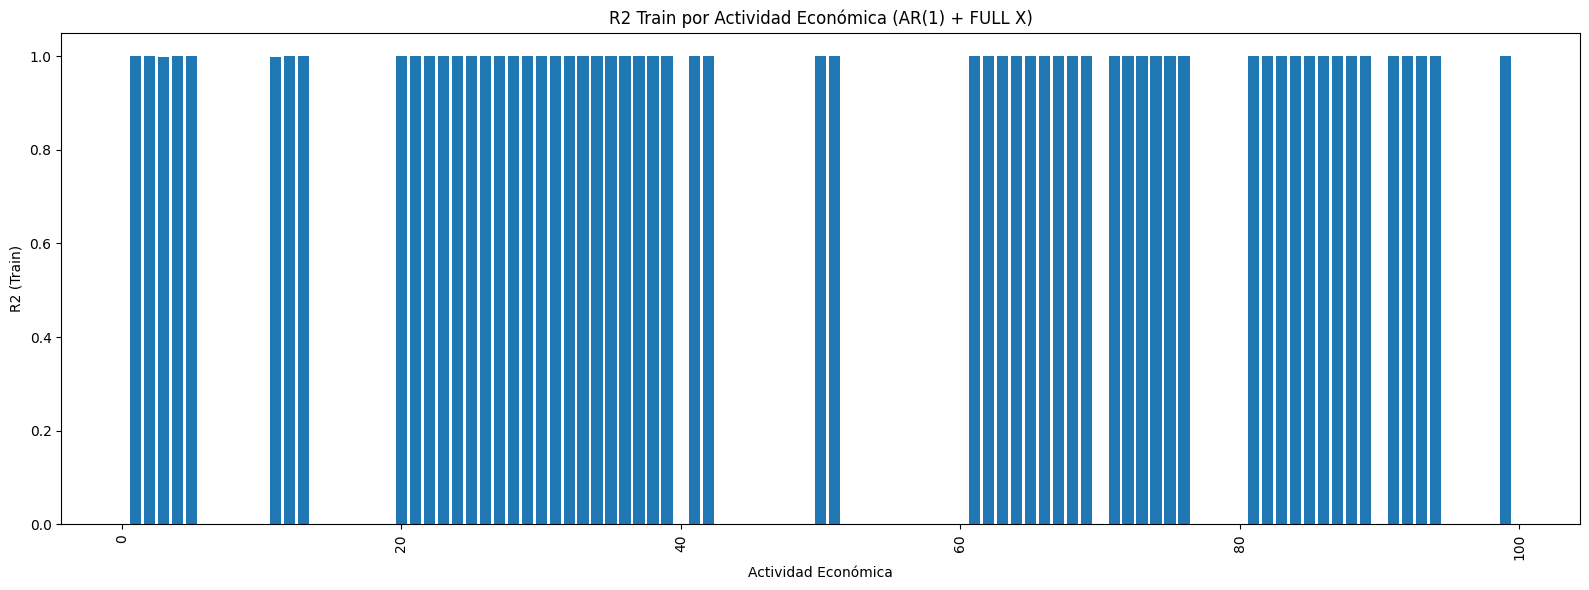

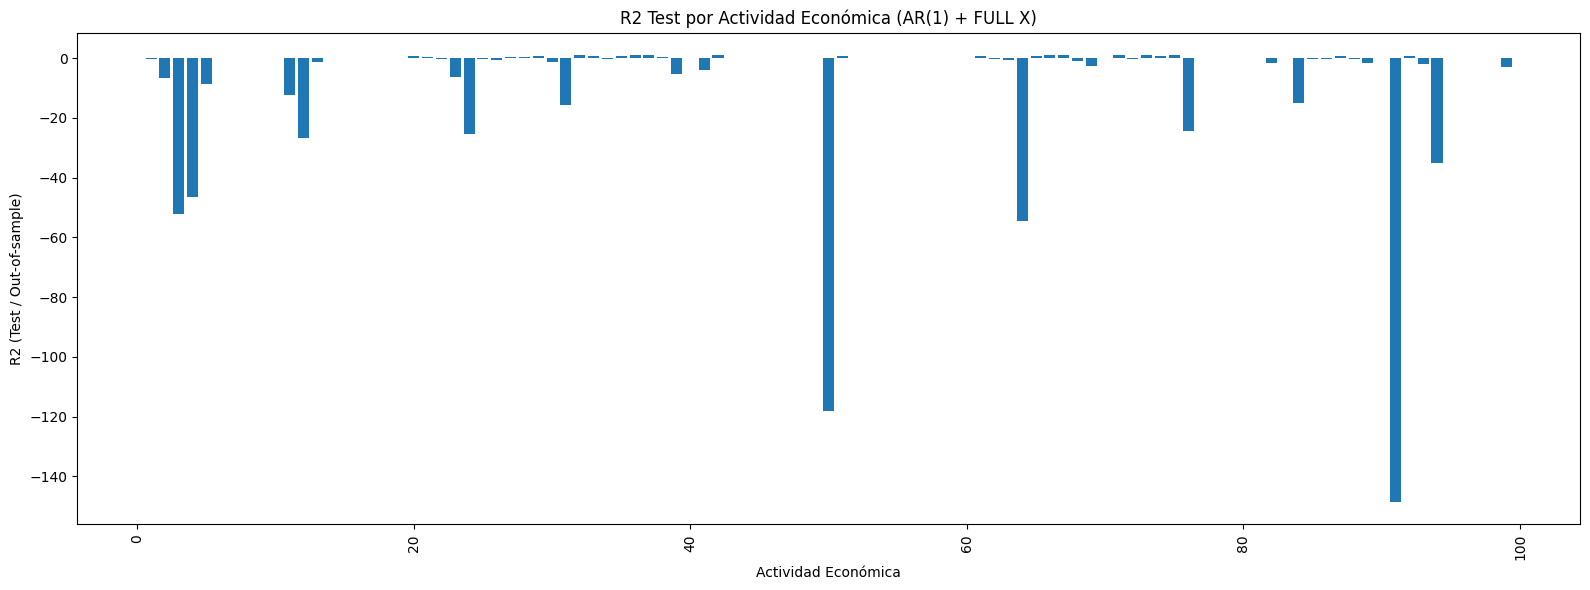

In [46]:
# ----------------------------
# 8) GRÁFICAS: R2 TRAIN y R2 TEST
# ----------------------------
summary_train = summary.sort_values("R2_train", ascending=False)
plt.figure(figsize=(16,6))
plt.bar(summary_train["Sector"], summary_train["R2_train"])
plt.xticks(rotation=90)
plt.ylabel("R2 (Train)")
plt.xlabel("Actividad Económica")
plt.title("R2 Train por Actividad Económica (AR(1) + FULL X)")
plt.tight_layout()
plt.show()

summary_test = summary.sort_values("R2_test", ascending=False)
plt.figure(figsize=(16,6))
plt.bar(summary_test["Sector"], summary_test["R2_test"])
plt.xticks(rotation=90)
plt.ylabel("R2 (Test / Out-of-sample)")
plt.xlabel("Actividad Económica")
plt.title("R2 Test por Actividad Económica (AR(1) + FULL X)")
plt.tight_layout()
plt.show()

# Optimización del Modelo

In [47]:
# ============================================
# SECTORES NO SIGNIFICATIVOS POR CADA SECTOR
# ============================================

insignificant_dict = {}

for sector in significance_matrix.index:
    # Sectores donde H0 NO se rechaza (FALSE)
    insignificant = significance_matrix.loc[sector]
    insignificant_sectors = insignificant[insignificant == False].index.tolist()

    # Quitamos la diagonal (porque siempre es False)
    if sector in insignificant_sectors:
        insignificant_sectors.remove(sector)

    insignificant_dict[sector] = insignificant_sectors

In [48]:
null_ratio = {}

for sector in significance_matrix.index:
    total = len(significance_matrix.columns) - 1  # menos diagonal
    non_sig = len(insignificant_dict[sector])
    null_ratio[sector] = non_sig / total

null_ratio_series = pd.Series(null_ratio).sort_values(ascending=False)

#print("Proporción de variables irrelevantes por sector:")
#display(null_ratio_series)

In [49]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

ALPHA = 0.05

def r2_oos(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res/ss_tot if ss_tot != 0 else np.nan

def _align_ar1_data(df_wide, target_code):
    """
    Construye Z alineado para el modelo AR(1) + X contemporáneas:
    Z = [y, y_lag1, X_all] con dropna por el rezago.
    """
    y = df_wide[target_code].copy()
    X_all = df_wide.drop(columns=[target_code]).copy()
    y_lag = y.shift(1).rename("y_lag1")

    Z = pd.concat([y.rename("y"), y_lag, X_all], axis=1).dropna()
    return Z

def fit_full_and_get_significant_vars(df_wide, target_code, n_train, alpha=0.05):
    """
    Estima FULL en TRAIN y regresa:
    - modelo_full
    - lista de variables contemporáneas significativas (p<alpha)
    - métricas train/test
    """
    if target_code not in df_wide.columns:
        return None

    Z = _align_ar1_data(df_wide, target_code)
    if Z.empty or len(Z) <= n_train + 1:
        return None

    y_aligned = Z["y"]
    X_aligned = Z.drop(columns=["y"])

    # split temporal en datos alineados
    y_train, y_test = y_aligned.iloc[:n_train], y_aligned.iloc[n_train:]
    X_train, X_test = X_aligned.iloc[:n_train], X_aligned.iloc[n_train:]

    # eliminar columnas constantes en TRAIN
    var = X_train.var(axis=0)
    X_train = X_train.loc[:, var > 0]
    X_test  = X_test.loc[:, X_train.columns]

    if X_train.shape[1] == 0 or len(y_test) == 0:
        return None

    X_train_c = sm.add_constant(X_train)
    X_test_c  = sm.add_constant(X_test)

    model_full = sm.OLS(y_train, X_train_c).fit()

    # predicciones
    y_pred_test = model_full.predict(X_test_c)

    # variables contemporáneas significativas (excluye const y y_lag1)
    pvals = model_full.pvalues.drop(labels=["const"], errors="ignore")
    pvals = pvals.drop(labels=["y_lag1"], errors="ignore")

    sig_vars = pvals[pvals < alpha].index.tolist()

    out = {
        "model_full": model_full,
        "sig_vars": sig_vars,
        "R2_train_full": float(model_full.rsquared),
        "R2_test_full": float(r2_oos(y_test.values, y_pred_test.values)),
        "n_sig_vars": int(len(sig_vars)),
        "n_regressors_full": int(X_train.shape[1])  # incluye y_lag1 + (N-1) - constantes
    }
    return out

def fit_reduced_given_vars(df_wide, target_code, n_train, selected_vars):
    """
    Re-estima usando:
    - siempre y_lag1
    - solo selected_vars (contemporáneas)
    """
    Z = _align_ar1_data(df_wide, target_code)
    if Z.empty or len(Z) <= n_train + 1:
        return None

    y_aligned = Z["y"]

    # Armamos X con y_lag1 + seleccionadas (si no existen, se ignoran)
    cols = ["y_lag1"] + [v for v in selected_vars if v in Z.columns]
    X_aligned = Z[cols].copy()

    y_train, y_test = y_aligned.iloc[:n_train], y_aligned.iloc[n_train:]
    X_train, X_test = X_aligned.iloc[:n_train], X_aligned.iloc[n_train:]

    # eliminar constantes en TRAIN
    var = X_train.var(axis=0)
    X_train = X_train.loc[:, var > 0]
    X_test  = X_test.loc[:, X_train.columns]

    # si quedó vacío (por ejemplo y_lag1 constante), no se puede estimar
    if X_train.shape[1] == 0 or len(y_test) == 0:
        return None

    X_train_c = sm.add_constant(X_train)
    X_test_c  = sm.add_constant(X_test)

    model_red = sm.OLS(y_train, X_train_c).fit()
    y_pred_test = model_red.predict(X_test_c)

    return {
        "model_reduced": model_red,
        "R2_train_reduced": float(model_red.rsquared),
        "R2_test_reduced": float(r2_oos(y_test.values, y_pred_test.values)),
        "n_regressors_reduced": int(X_train.shape[1])  # incluye y_lag1 + seleccionadas - constantes
    }

# ============================================
# EJECUCIÓN PARA TODOS LOS SECTORES
# ============================================
sector_codes = sorted(wide.columns.tolist())

rows = []
kept_vars_by_sector = {}  # para que tengas el listado final por sector

for code in sector_codes:
    full = fit_full_and_get_significant_vars(wide, code, N_TRAIN, alpha=ALPHA)
    if full is None:
        continue

    sig_vars = full["sig_vars"]
    kept_vars_by_sector[code] = sig_vars

    # Modelo reducido: si no hay sig_vars => solo AR(1)
    reduced = fit_reduced_given_vars(wide, code, N_TRAIN, selected_vars=sig_vars)

    # Si por algo raro no se pudo estimar el reducido, lo dejamos como NaN
    if reduced is None:
        reduced_metrics = {"R2_train_reduced": np.nan, "R2_test_reduced": np.nan, "n_regressors_reduced": 0}
    else:
        reduced_metrics = reduced

    rows.append({
        "Sector_code": int(code),
        "Sector": activity_names.get(int(code), f"ACT_{int(code)}"),
        "R2_train_full": full["R2_train_full"],
        "R2_test_full": full["R2_test_full"],
        "n_regressors_full": full["n_regressors_full"],
        "n_sig_vars": full["n_sig_vars"],
        "R2_train_reduced": reduced_metrics["R2_train_reduced"],
        "R2_test_reduced": reduced_metrics["R2_test_reduced"],
        "n_regressors_reduced": reduced_metrics["n_regressors_reduced"],
        "Delta_R2_test": (reduced_metrics["R2_test_reduced"] - full["R2_test_full"]) if np.isfinite(reduced_metrics["R2_test_reduced"]) else np.nan
    })

comparison = pd.DataFrame(rows).sort_values("Delta_R2_test", ascending=False).reset_index(drop=True)

#print("Comparación FULL vs REDUCIDO (por significancia p<0.05 en TRAIN):")
#display(comparison)

# ============================================
# EXTRA: ¿Qué sectores se pueden 'dar por nulos' (candidatos a eliminar) por cada sector i?
# (Son los NO significativos: todos menos sig_vars y menos el propio sector)
# ============================================
all_vars = set(sector_codes)

insignificant_by_sector = {}

for code in sector_codes:
    if code not in kept_vars_by_sector:
        continue
    sig = set(kept_vars_by_sector[code])
    # Candidatos a eliminar = todos los otros sectores contemporáneos que NO son significativos
    # (Excluimos el propio code)
    insig = sorted(list((all_vars - {code}) - sig))
    # los convertimos a nombres para que sea legible
    insig_named = [activity_names.get(int(k), f"ACT_{int(k)}") for k in insig]
    insignificant_by_sector[activity_names.get(int(code), f"ACT_{int(code)}")] = insig_named

# Ejemplo: mostrar 5 sectores con más eliminables
tmp = {k: len(v) for k, v in insignificant_by_sector.items()}
top5 = sorted(tmp.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 sectores con MÁS variables candidatas a eliminar (por no significancia):")
for sec, n in top5:
    print(f"- {sec}: {n}")

# Si quieres ver la lista completa para un sector en específico:
# print(insignificant_by_sector["GANADERIA"])

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss



Top 5 sectores con MÁS variables candidatas a eliminar (por no significancia):
- ACT_14: 61
- ACT_25: 56
- ACT_32: 56
- ACT_36: 56
- ACT_13: 55


In [50]:
comparison_summary_test = comparison.sort_values("R2_test_full", ascending=False)
print("Comparación FULL vs REDUCIDO (por significancia p<0.05 en TRAIN):")
comparison_summary_test

Comparación FULL vs REDUCIDO (por significancia p<0.05 en TRAIN):


,Sector_code,Sector,R2_train_full,R2_test_full,n_regressors_full,n_sig_vars,R2_train_reduced,R2_test_reduced,n_regressors_reduced,Delta_R2_test
52,66,ACT_66,0.999999,0.998658,61,7,0.999976,0.993580,8,-0.005078
51,32,ACT_32,0.999998,0.996503,61,5,0.999949,0.995206,6,-0.001297
50,37,ACT_37,0.999994,0.996156,61,16,0.999953,0.997311,17,0.001155
54,36,ACT_36,0.999991,0.988793,61,5,0.999887,0.923286,6,-0.065508
55,42,ACT_42,0.999999,0.976019,61,16,0.999995,0.893533,17,-0.082486
...,...,...,...,...,...,...,...,...,...,...
2,3,ACT_3,0.999348,-52.052299,61,7,0.996417,0.926234,8,52.978533
3,64,ACT_64,0.999993,-54.587437,61,13,0.999959,-2.171462,14,52.415974
1,50,ACT_50,0.999821,-118.140387,61,19,0.999351,-2.075191,20,116.065196
0,91,ACT_91,0.999948,-148.590691,61,16,0.999810,-9.389960,17,139.200731


In [51]:
comparison_summary_test

,Sector_code,Sector,R2_train_full,R2_test_full,n_regressors_full,n_sig_vars,R2_train_reduced,R2_test_reduced,n_regressors_reduced,Delta_R2_test
52,66,ACT_66,0.999999,0.998658,61,7,0.999976,0.993580,8,-0.005078
51,32,ACT_32,0.999998,0.996503,61,5,0.999949,0.995206,6,-0.001297
50,37,ACT_37,0.999994,0.996156,61,16,0.999953,0.997311,17,0.001155
54,36,ACT_36,0.999991,0.988793,61,5,0.999887,0.923286,6,-0.065508
55,42,ACT_42,0.999999,0.976019,61,16,0.999995,0.893533,17,-0.082486
...,...,...,...,...,...,...,...,...,...,...
2,3,ACT_3,0.999348,-52.052299,61,7,0.996417,0.926234,8,52.978533
3,64,ACT_64,0.999993,-54.587437,61,13,0.999959,-2.171462,14,52.415974
1,50,ACT_50,0.999821,-118.140387,61,19,0.999351,-2.075191,20,116.065196
0,91,ACT_91,0.999948,-148.590691,61,16,0.999810,-9.389960,17,139.200731


In [52]:
comparison_summary_test.R2_test_reduced.describe()

,R2_test_reduced
count,61.000000
mean,-0.486398
std,3.234893
min,-14.644356
25%,-0.041533
50%,0.839134
75%,0.960142
max,0.999384


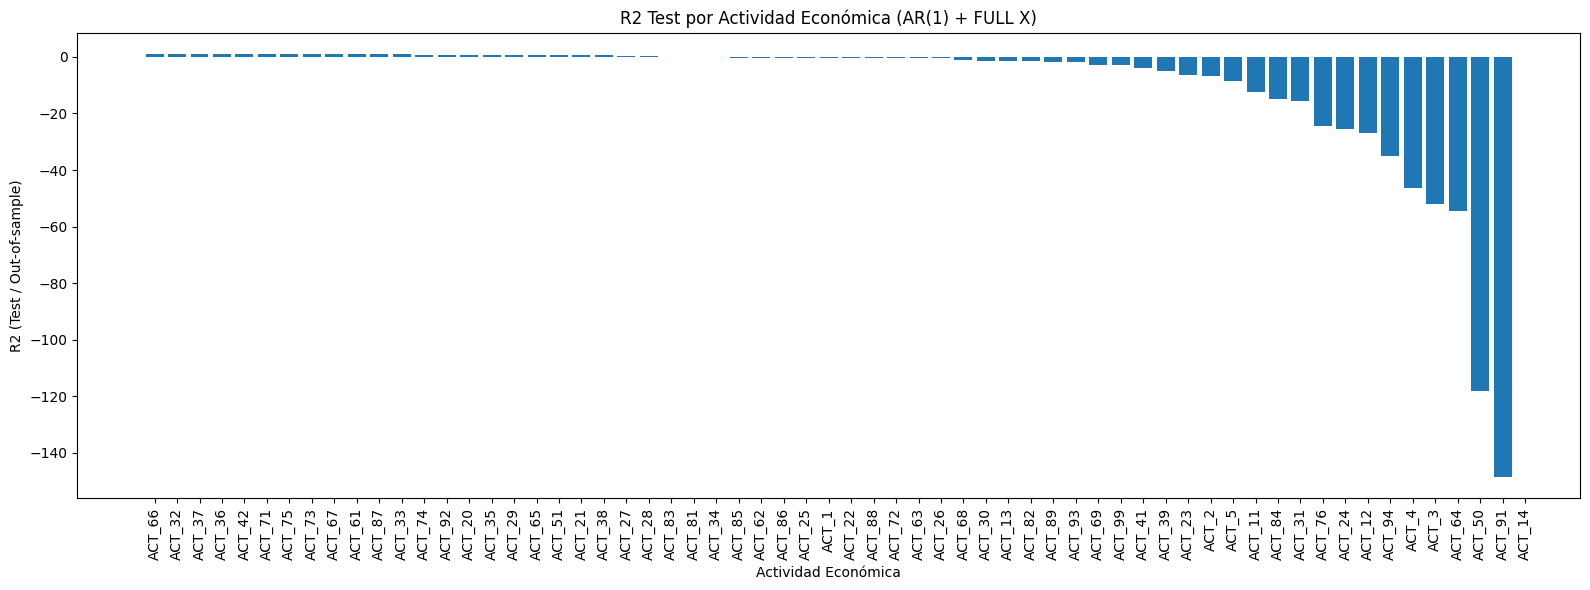

In [53]:
comparison_summary_test = comparison.sort_values("R2_test_full", ascending=False)
plt.figure(figsize=(16,6))
plt.bar(comparison_summary_test["Sector"], comparison_summary_test["R2_test_full"])
plt.xticks(rotation=90)
plt.ylabel("R2 (Test / Out-of-sample)")
plt.xlabel("Actividad Económica")
plt.title("R2 Test por Actividad Económica (AR(1) + FULL X)")
plt.tight_layout()
plt.show()

In [54]:
comparison_summary_test.describe()

,Sector_code,R2_train_full,R2_test_full,n_regressors_full,n_sig_vars,R2_train_reduced,R2_test_reduced,n_regressors_reduced,Delta_R2_test
count,62.000000,61.000000,61.000000,62.0,62.000000,61.000000,61.000000,62.000000,61.000000
mean,49.983871,0.999926,-9.928136,61.0,12.741935,0.999376,-0.486398,13.725806,9.441739
std,29.206159,0.000313,26.429050,0.0,4.945392,0.003092,3.234893,4.989068,25.281138
min,1.000000,0.997624,-148.590691,61.0,0.000000,0.975947,-14.644356,0.000000,-15.238662
25%,26.250000,0.999967,-5.159727,61.0,9.250000,0.999709,-0.041533,10.250000,0.064947
50%,46.000000,0.999991,-0.409169,61.0,13.000000,0.999931,0.839134,14.000000,0.913625
75%,74.750000,0.999996,0.739682,61.0,16.000000,0.999977,0.960142,17.000000,4.473622
max,99.000000,0.999999,0.998658,61.0,24.000000,0.999996,0.999384,25.000000,139.200731


In [55]:
comparison_summary_test

,Sector_code,Sector,R2_train_full,R2_test_full,n_regressors_full,n_sig_vars,R2_train_reduced,R2_test_reduced,n_regressors_reduced,Delta_R2_test
52,66,ACT_66,0.999999,0.998658,61,7,0.999976,0.993580,8,-0.005078
51,32,ACT_32,0.999998,0.996503,61,5,0.999949,0.995206,6,-0.001297
50,37,ACT_37,0.999994,0.996156,61,16,0.999953,0.997311,17,0.001155
54,36,ACT_36,0.999991,0.988793,61,5,0.999887,0.923286,6,-0.065508
55,42,ACT_42,0.999999,0.976019,61,16,0.999995,0.893533,17,-0.082486
...,...,...,...,...,...,...,...,...,...,...
2,3,ACT_3,0.999348,-52.052299,61,7,0.996417,0.926234,8,52.978533
3,64,ACT_64,0.999993,-54.587437,61,13,0.999959,-2.171462,14,52.415974
1,50,ACT_50,0.999821,-118.140387,61,19,0.999351,-2.075191,20,116.065196
0,91,ACT_91,0.999948,-148.590691,61,16,0.999810,-9.389960,17,139.200731


In [59]:
from google.colab import drive
drive.mount('/content/drive')

comparison_summary_test.R2_test_full.to_excel("/content/drive/MyDrive/r2_test.xlsx", index=False)
comparison_summary_test.R2_train_full.to_excel("/content/drive/MyDrive/r2_train.xlsx", index=False)

Mounted at /content/drive
